# Imports

In [58]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns	
from scipy import stats
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, auc, roc_auc_score, roc_curve, make_scorer, precision_recall_curve, roc_auc_score, log_loss
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import warnings
warnings.filterwarnings('ignore')

# Tabela

In [59]:
df = pd.read_csv('synthetic_coffee_health_10000(in).csv')
df

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,50,Female,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,0,1
9996,9997,18,Female,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,0,0
9997,9998,26,Male,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,NaN,Student,1,1
9998,9999,40,Female,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,NaN,Student,0,0


## Metadados

In [60]:
def get_metadata(df, alpha=0.05, min_samples=20):
    colunas = df.columns
    tipos = [df[col].dtype.name for col in colunas]   # cleaner dtype names
    
    # Compute null counts once
    null_counts = df.isnull().sum()
    total_rows = df.shape[0]
    pct_nulls = (null_counts / total_rows * 100).round(2)
    
    cardinalidade = df.nunique()
    
    def test_normality(coluna):
        dtype = df[coluna].dtype
        if not pd.api.types.is_numeric_dtype(dtype):
            return None
        values = df[coluna].dropna()
        if len(values) < min_samples:
            return None
        stat, p = stats.normaltest(values)
        return p > alpha   # True if we cannot reject normality
    
    fl_normal = [test_normality(col) for col in colunas]
    
    metadata = pd.DataFrame({
        'Nome_Variavel': colunas,
        'Tipo_Dado': tipos,
        'Qtd_Nulos': null_counts.values,
        'Pct_Nulos': pct_nulls.values,
        'Cardinalidade': cardinalidade.values,
        'Normal': fl_normal
    })
    
    metadata = metadata.sort_values(by='Pct_Nulos', ascending=False).reset_index(drop=True)
    return metadata

# Usage
metadados_01 = get_metadata(df)
metadados_01

,Nome_Variavel,Tipo_Dado,Qtd_Nulos,Pct_Nulos,Cardinalidade,Normal
0,Health_Issues,object,5941,59.41,3,None
1,ID,int64,0,0.00,10000,False
2,Age,int64,0,0.00,59,False
3,Gender,object,0,0.00,3,None
4,Country,object,0,0.00,20,None
5,Coffee_Intake,float64,0,0.00,78,False
6,Caffeine_mg,float64,0,0.00,4277,False
7,Sleep_Hours,float64,0,0.00,71,False
8,Sleep_Quality,object,0,0.00,4,None
9,BMI,float64,0,0.00,220,False


# Tratamento de Nulos

In [61]:
# ----------------------------
# 1. Função de imputação por sorteio condicional
# ----------------------------
def impute_health_issues(df, group_cols, target_col='Health_Issues', seed=42):
    """
    Preenche os NAs da coluna alvo sorteando valores dentro de cada grupo,
    respeitando as proporções observadas naquele grupo.
    
    Parâmetros:
    - df: DataFrame original
    - group_cols: lista com os nomes das colunas usadas para agrupar
    - target_col: nome da coluna a ser imputada
    - seed: semente para reprodutibilidade
    
    Retorna:
    - DataFrame com a coluna alvo totalmente preenchida
    """
    np.random.seed(seed)
    df_imputado = df.copy()
    
    # Calcula a moda geral (fallback para grupos sem dados)
    moda_geral = df[target_col].mode()[0]
    
    # Agrupa e preenche grupo por grupo
    for _, indices_grupo in df_imputado.groupby(group_cols).groups.items():
        # Filtra as linhas deste grupo
        grupo = df_imputado.loc[indices_grupo]
        
        # Valores não-nulos do grupo
        valores_validos = grupo[target_col].dropna()
        
        if len(valores_validos) > 0:
            # Calcula as proporções desse grupo
            proporcoes = valores_validos.value_counts(normalize=True)
            
            # Identifica quais linhas do grupo têm NA
            mascara_na = grupo[target_col].isna()
            qtd_nas = mascara_na.sum()
            
            if qtd_nas > 0:
                # Sorteia novos valores de acordo com as proporções do grupo
                valores_sorteados = np.random.choice(
                    proporcoes.index,
                    size=qtd_nas,
                    p=proporcoes.values
                )
                # Atribui ao DataFrame original
                df_imputado.loc[
                    grupo[mascara_na].index, target_col
                ] = valores_sorteados
    
    # Fallback final: se ainda restar algum NA (ex: grupo sem dados completos)
    df_imputado[target_col] = df_imputado[target_col].fillna(moda_geral)
    
    return df_imputado

# ----------------------------
# 2. Aplicar a função com 5 variáveis
# ----------------------------
# Defina as 5 colunas que vão formar os grupos
colunas_agrupamento = [
    'Stress_Level',
    'Sleep_Quality',
    'Smoking',
    'Gender',
    'Occupation'
]

# Aplica a imputação
df_imputado = impute_health_issues(
    df, 
    group_cols=colunas_agrupamento,
    target_col='Health_Issues',
    seed=42
)

# Verifica se todos os NAs foram preenchidos
# print(f"Nulos restantes em Health_Issues: {df_imputado['Health_Issues'].isna().sum()}")

metadados_02 = get_metadata(df_imputado)

df = df_imputado
metadados_02

,Nome_Variavel,Tipo_Dado,Qtd_Nulos,Pct_Nulos,Cardinalidade,Normal
0,ID,int64,0,0.0,10000,False
1,Age,int64,0,0.0,59,False
2,Gender,object,0,0.0,3,None
3,Country,object,0,0.0,20,None
4,Coffee_Intake,float64,0,0.0,78,False
5,Caffeine_mg,float64,0,0.0,4277,False
6,Sleep_Hours,float64,0,0.0,71,False
7,Sleep_Quality,object,0,0.0,4,None
8,BMI,float64,0,0.0,220,False
9,Heart_Rate,int64,0,0.0,58,False


# 1. EDA

## Variáveis Numéricas

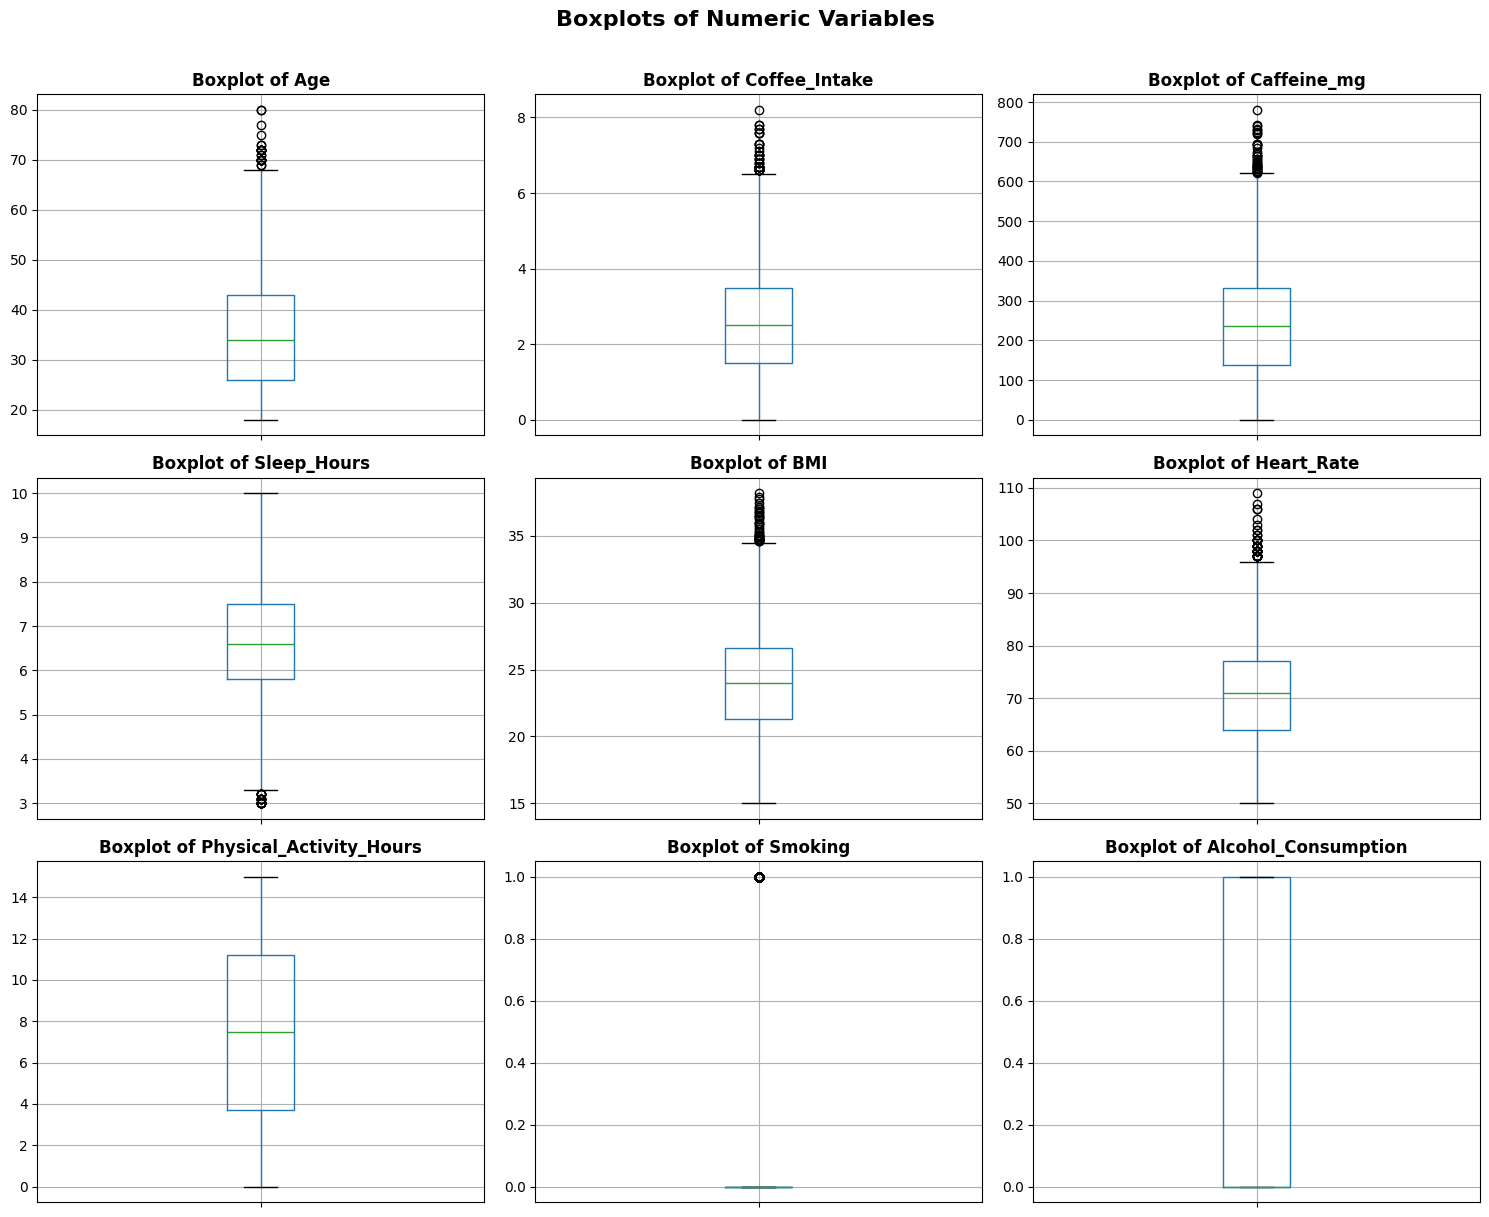

In [62]:
num_cols = [col for col, dtype in df.dtypes.items() if dtype in ['int64', 'float64'] and col != ('ID')]

n = len(num_cols)
ncols = 3
nrows = -(-n//ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', labelbottom=False)

for j in range(i+1, len(axes)):
    axes[j].axis('off')
    
plt.suptitle('Boxplots of Numeric Variables', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

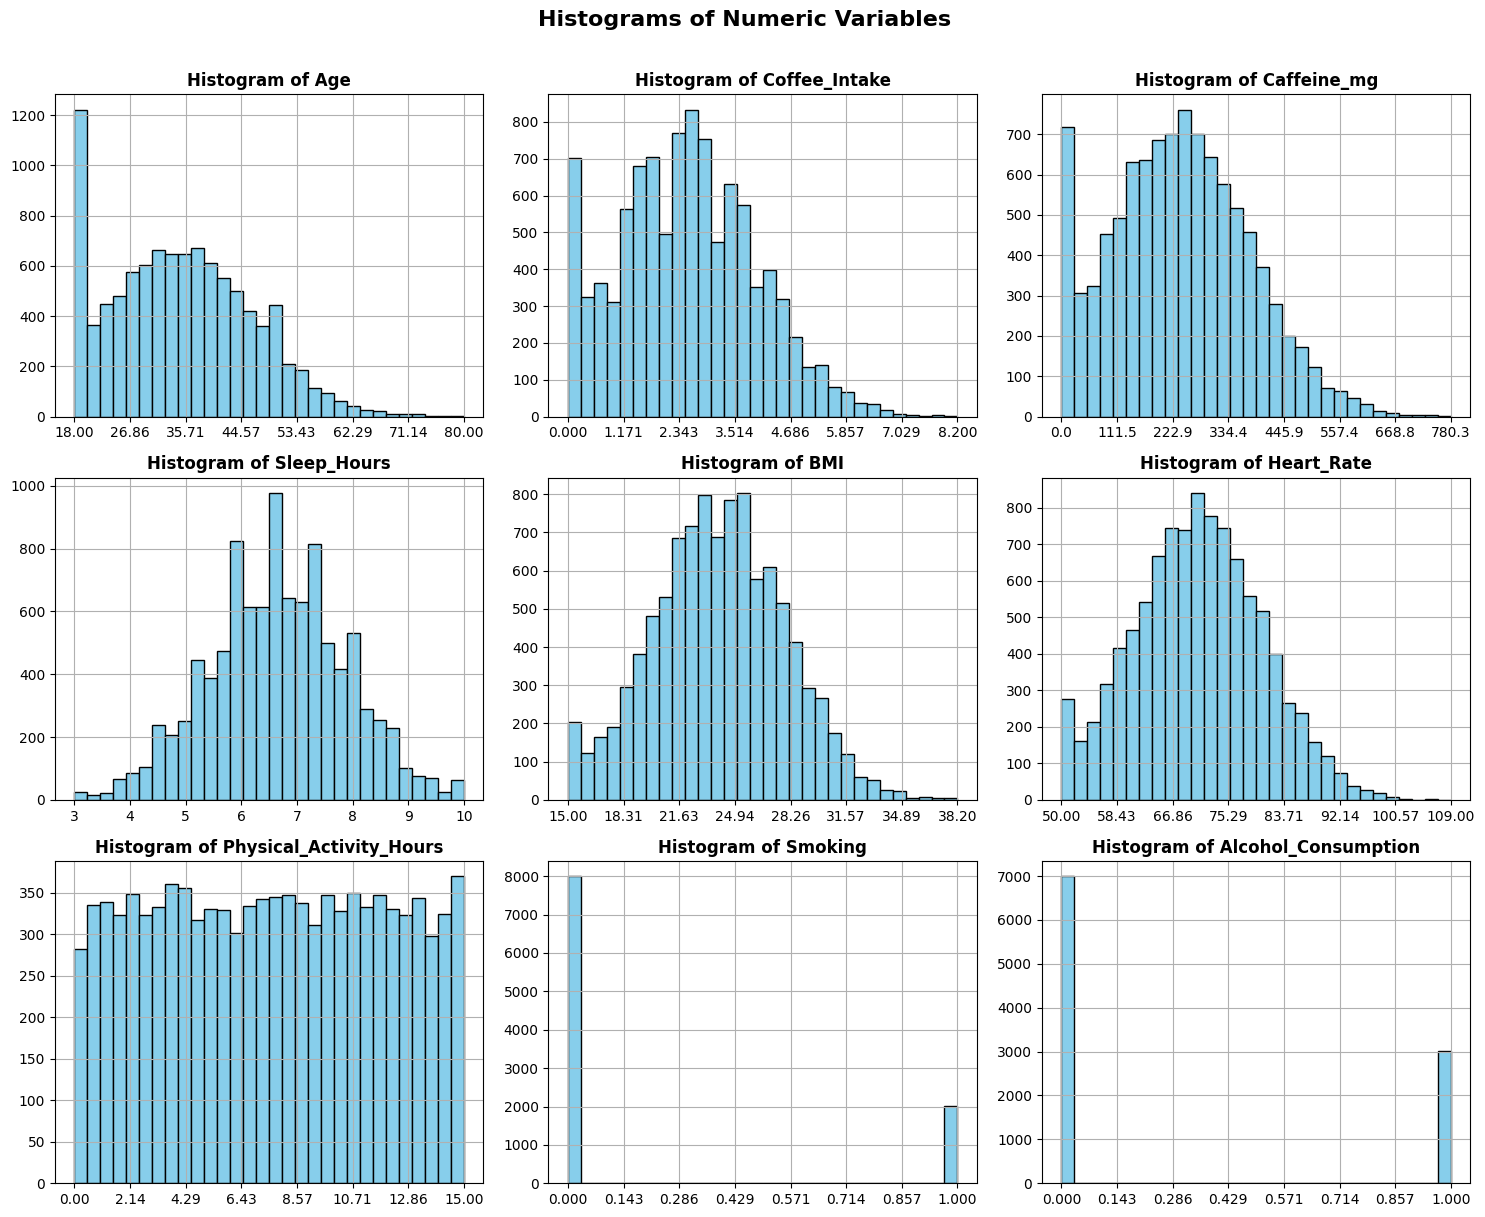

In [63]:
fig2, axes2 = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
axes2 = axes2.flatten()

for i, col in enumerate(num_cols):
    df[[col]].hist(ax=axes2[i], bins=30, color='skyblue', edgecolor='black')
    axes2[i].set_title(f'Histogram of {col}', fontsize=12, fontweight='bold')
    axes2[i].tick_params(axis='x')
    
    bin_edges = axes2[i].patches[0].get_path().vertices[:, 0]
    if len(bin_edges) > 0:
        axes2[i].set_xticks(np.linspace(df[col].min(), df[col].max(), 8))

for j in range(i+1, len(axes2)):
    axes2[j].set_visible(False)

plt.suptitle('Histograms of Numeric Variables', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Variáveis Categóricas

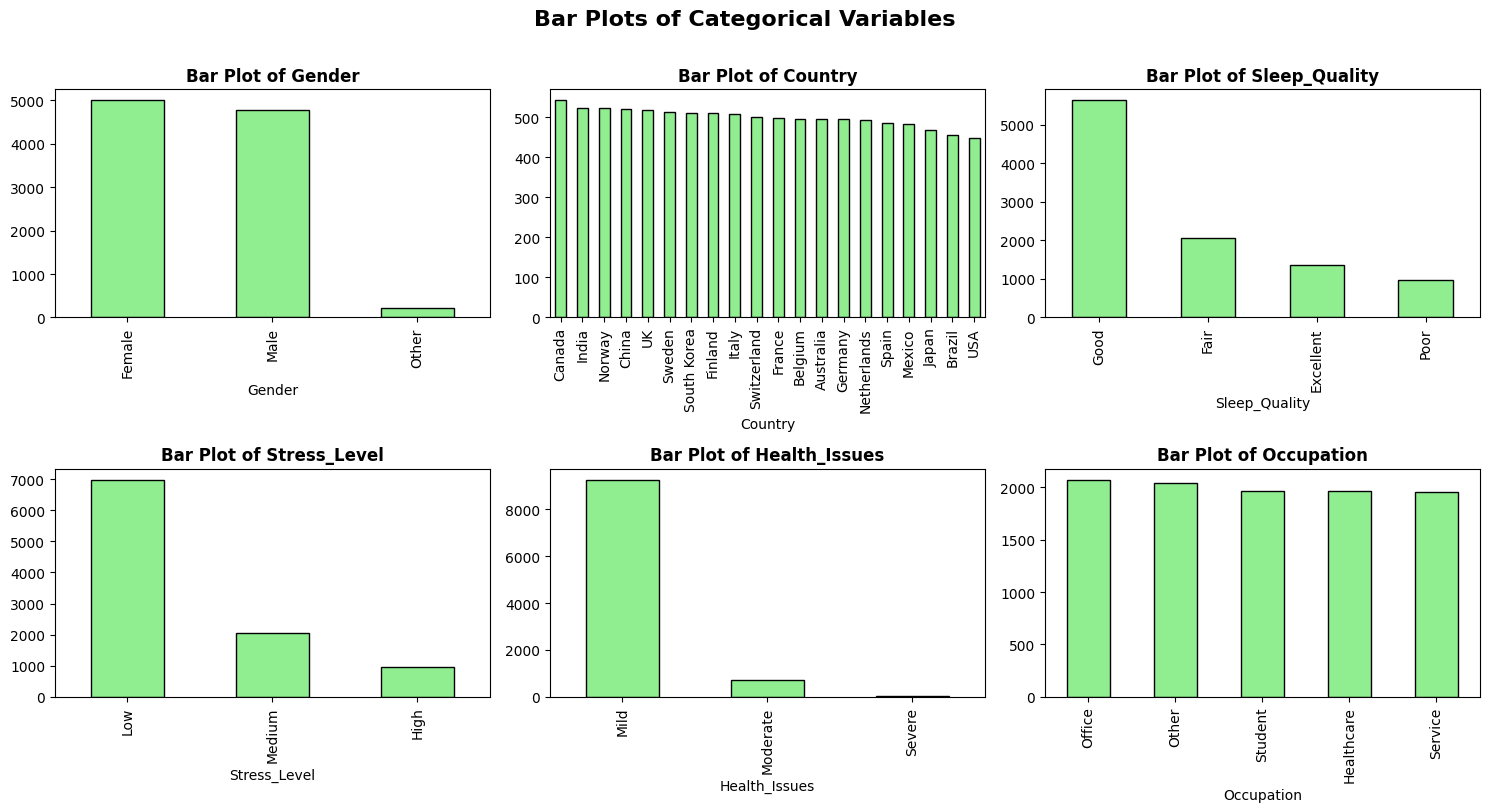

In [64]:
cat_cols = [col for col, dtype in df.dtypes.items() if dtype == 'object']

n = len(cat_cols)
ncols = 3
nrows = -(-n//ncols)

fig3, axes3 = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 4*nrows))
axes3 = axes3.flatten()

for i, col in enumerate(cat_cols):
	df[col].value_counts().plot(kind='bar', ax=axes3[i], color='lightgreen', edgecolor='black')
	axes3[i].set_title(f'Bar Plot of {col}', fontsize=12, fontweight='bold')
	axes3[i].tick_params(axis='x')

for j in range(i+1, len(axes3)):
	axes3[j].set_visible(False)

plt.suptitle('Bar Plots of Categorical Variables', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Multi Variáveis

In [65]:
def plot_grid_misto(
		df: pd.DataFrame,
		num_vars: list,
		cat_vars: list,
		corner: bool=False,
		cell_size: float=3.5,
		scatter_kws: dict=None,
		max_cat_labels: int=10,
		annot_heatmap: bool=True,
		title: str=None
):
	all_vars = list(num_vars) + list(cat_vars)
	missing = [v for v in all_vars if v not in df.columns]
	if missing:
		raise ValueError(f"Variables not found in DataFrame: {missing}")
	if len(all_vars) < 2:
		raise ValueError("At least two variables are required for plotting.")
	
	scatter_kws = {'alpha': 0.4, 's': 15, **(scatter_kws or {})}
	num_set = set(num_vars)
	n = len(all_vars)
		
	fig, axes = plt.subplots(n, n, figsize=(cell_size*n, cell_size*n))
	axes = np.atleast_2d(axes)
		
	for i, var_y in enumerate(all_vars):
		for j, var_x in enumerate(all_vars):
			ax = axes[i, j]

			if corner and j>i:
				ax.set_visible(False)
				continue
		
			x_num = var_x in num_set
			y_num = var_y in num_set

			if i == j:
				if x_num:
					sns.histplot(df[var_x].dropna(), kde=True, ax=ax, color='steelblue')
				else:
					ordem = df[var_x].value_counts().index
					sns.countplot(data=df, x=var_x, order=ordem, ax=ax, color='steelblue')
				ax.set_title(var_x, fontsize=10, fontweight='bold')

			elif x_num and y_num:
				sns.scatterplot(data=df, x=var_x, y=var_y, ax=ax, **scatter_kws)

			elif x_num != y_num:
				cat, num = (var_x, var_y) if not x_num else (var_y, var_x)
				n_cats = df[cat].nunique()
				sns.boxplot(data=df, x=cat, y=num, ax=ax, palette='Set2')
				if n_cats > max_cat_labels:
					ax.set_xticklabels([])

			else:
				ct = pd.crosstab(df[var_y], df[var_x], normalize='index')
				muitas_cats = max(ct.shape) > max_cat_labels
				sns.heatmap(ct, ax=ax, cmap='Blues', cbar=False, vmin=0, vmax=1, annot=(annot_heatmap and not muitas_cats), fmt='.2f', annot_kws={'size':8})
			
			ax.tick_params(axis='x', rotation=45, labelsize=8)
			ax.tick_params(axis='y', labelsize=8)
			ax.set_xlabel(var_x if i ==n -1 else '', fontsize=9)
			ax.set_ylabel(var_y if j == 0 else '', fontsize=9)
			if i != n-1:
				ax.set_xticklabels([])

	if title:
		fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)
	
	plt.tight_layout()
	return fig, axes

### BMI vs Sleep_Hours/Sleep_Quality/Health_Issues/Heart_Rate/Physical_Activity_Hours

In [71]:
# num_vars1 = ['BMI', 'Sleep_Hours', 'Heart_Rate', 'Physical_Activity_Hours']
# cat_vars1 = ['Sleep_Quality', 'Health_Issues']

# fig1, axes1 = plot_grid_misto(df, num_vars1, cat_vars1, title='Mixed Grid Plot of Numeric and Categorical Variables')
# plt.show()

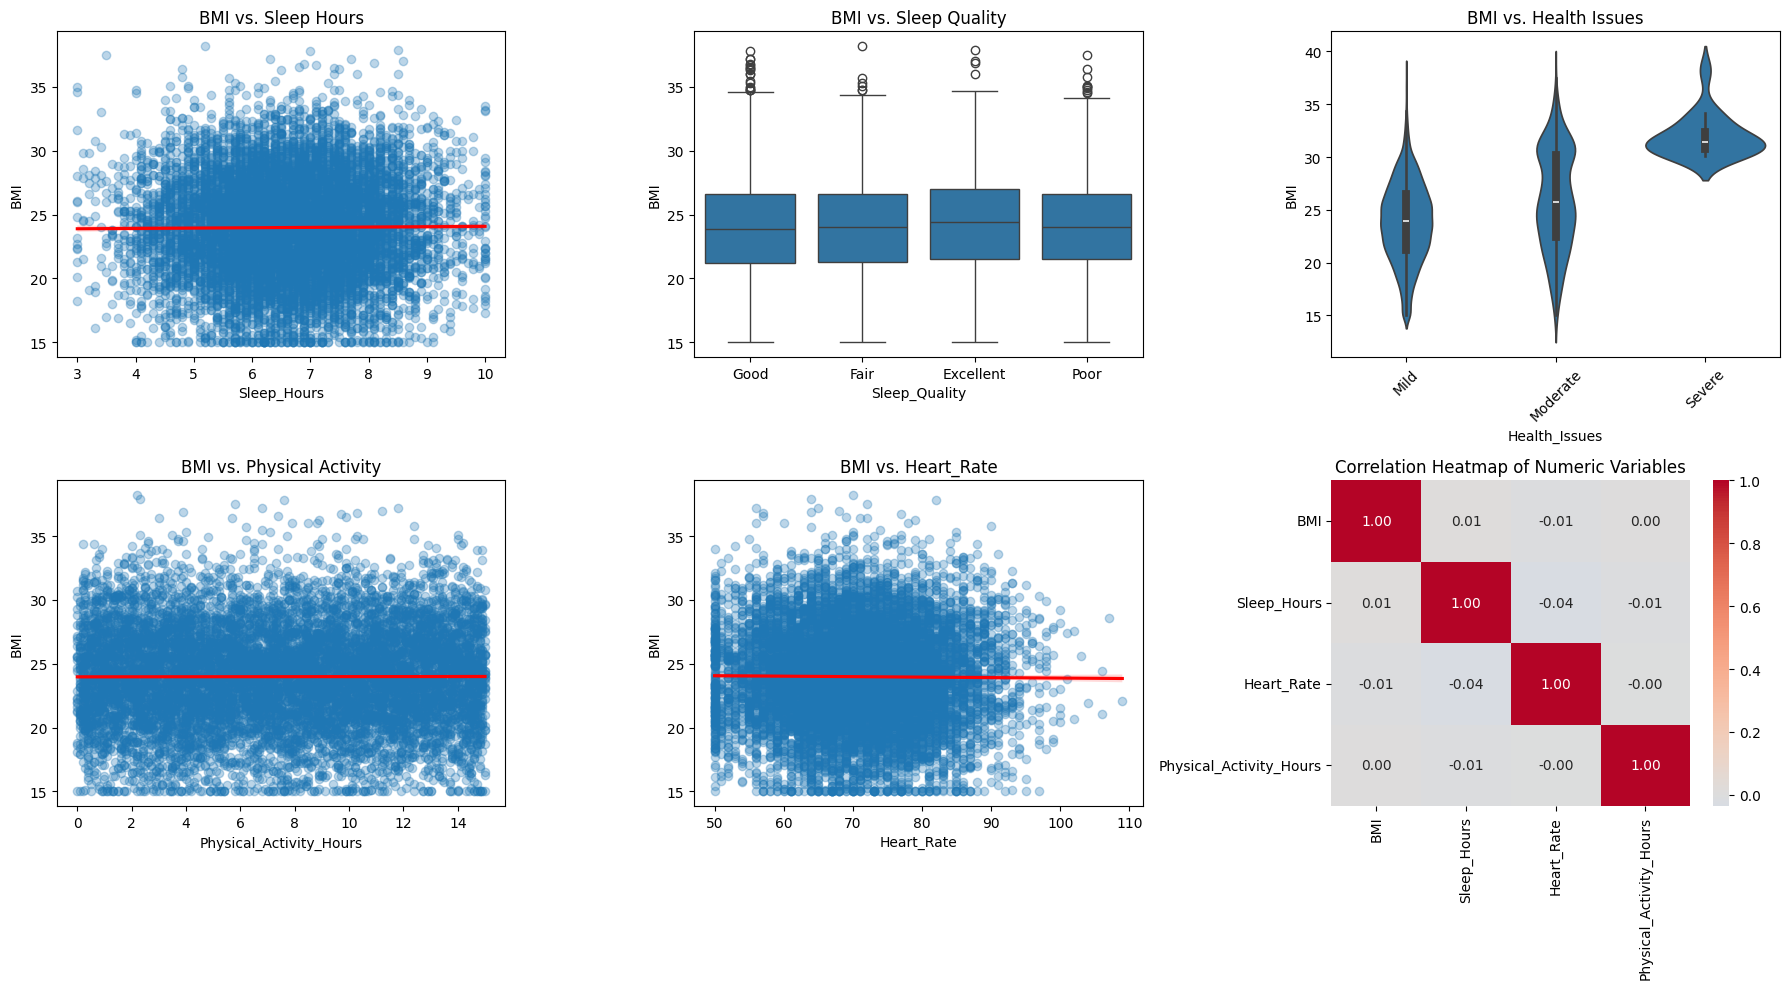

In [74]:
fig1, axes1 = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
fig.suptitle('BMI Analysis vs. Health Variables and Life Style', fontsize=16, fontweight='bold', y=1.02)

sns.regplot(data=df, x='Sleep_Hours', y='BMI', ax=axes1[0, 0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes1[0, 0].set_title('BMI vs. Sleep Hours')

sns.boxplot(data=df, x='Sleep_Quality', y='BMI', ax=axes1[0, 1])
axes1[0, 1].set_title('BMI vs. Sleep Quality')

sns.violinplot(data=df, x='Health_Issues', y='BMI', ax=axes1[0, 2])
axes1[0, 2].set_title('BMI vs. Health Issues')
axes1[0, 2].tick_params(axis='x', rotation=45)

sns.regplot(data=df, x='Physical_Activity_Hours', y='BMI', ax=axes1[1, 0], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes1[1, 0].set_title('BMI vs. Physical Activity')

sns.regplot(data=df, x='Heart_Rate', y='BMI', ax=axes1[1, 1], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
axes1[1, 1].set_title('BMI vs. Heart_Rate')

cols_num = ['BMI', 'Sleep_Hours', 'Heart_Rate', 'Physical_Activity_Hours']
sns.heatmap(df[cols_num].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes1[1, 2])
axes1[1, 2].set_title('Correlation Heatmap of Numeric Variables')

plt.tight_layout()
plt.show()

### Smoking vs Alcohol vs Health_Issues/Age/Physical_Activity_Hours

In [67]:
# num_vars2 = ['Smoking', 'Alcohol_Consumption', 'Age', 'Physical_Activity_Hours']
# cat_vars2 = ['Health_Issues']

# fig2, axes2 = plot_grid_misto(df, num_vars2, cat_vars2, title='Mixed Grid Plot of Numeric and Categorical Variables')
# plt.show()

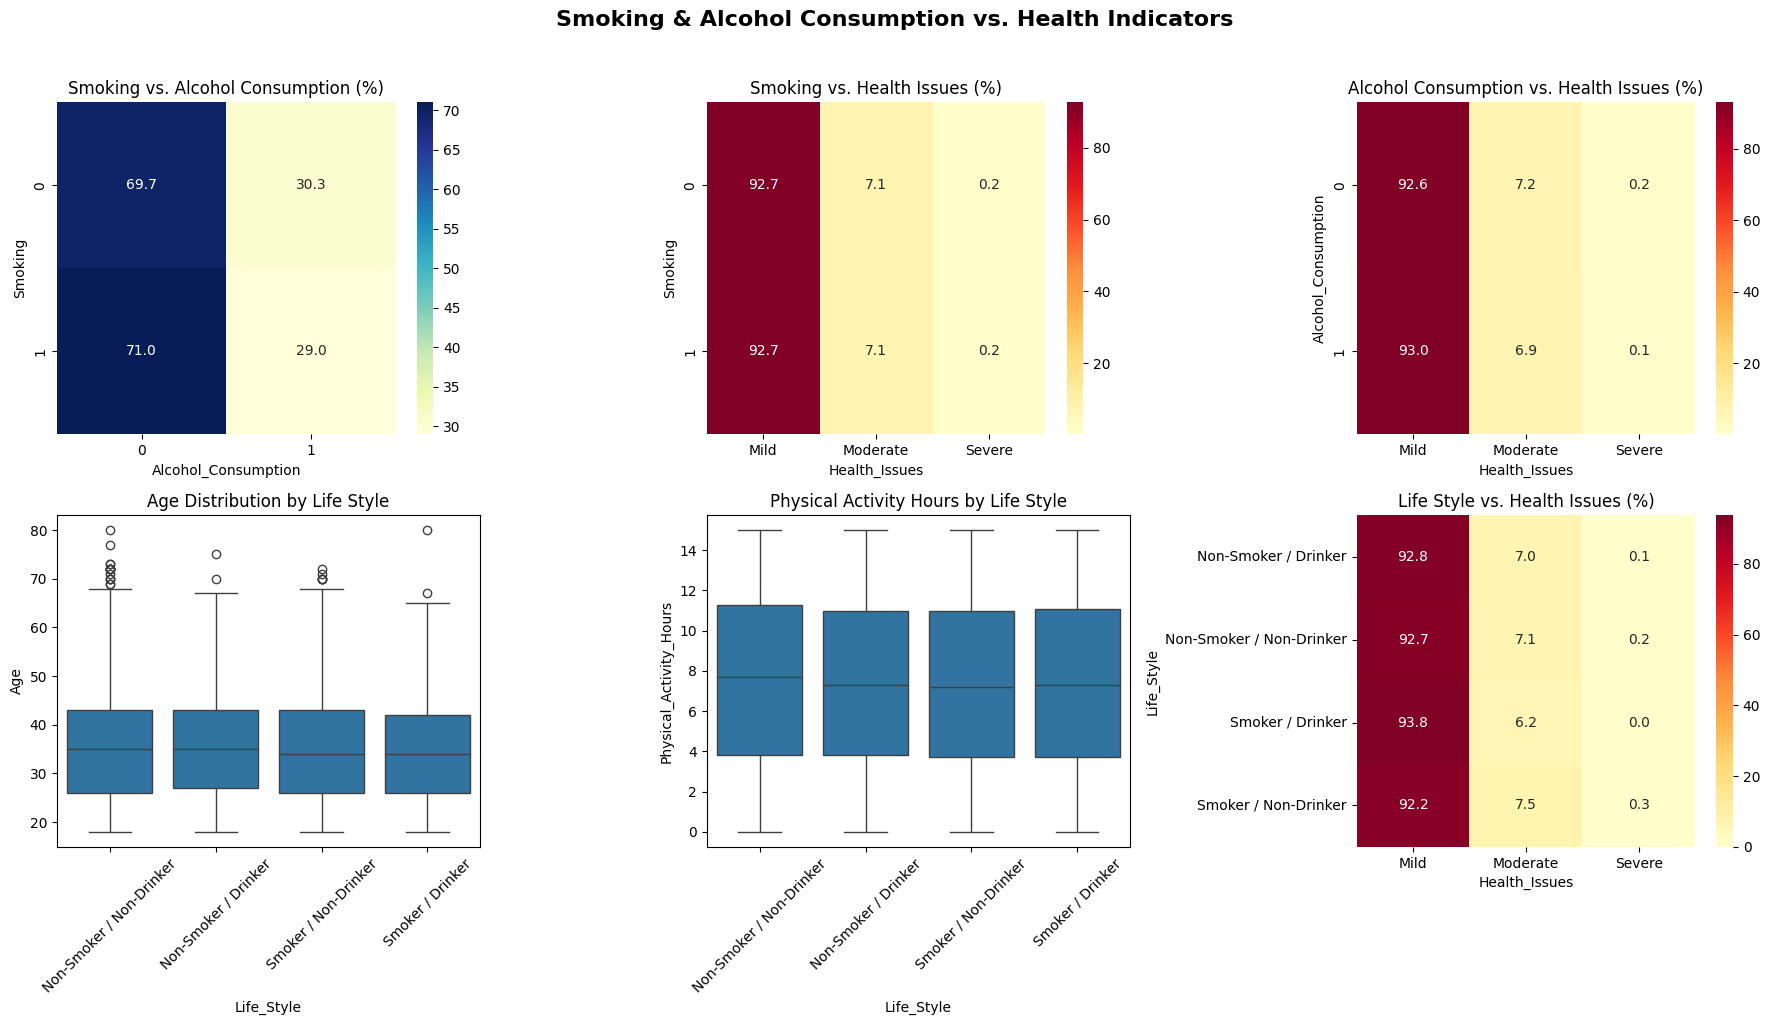

In [76]:
fig2, axes2 = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
fig2.suptitle('Smoking & Alcohol Consumption vs. Health Indicators', fontsize=16, fontweight='bold', y=1.02)

df['Life_Style'] = df['Smoking'].map({1: 'Smoker', 0: 'Non-Smoker'}) + ' / ' + df['Alcohol_Consumption'].map({1: 'Drinker', 0: 'Non-Drinker'})

ordem = ['Non-Smoker / Non-Drinker', 'Non-Smoker / Drinker', 'Smoker / Non-Drinker', 'Smoker / Drinker']

ct = pd.crosstab(df['Smoking'], df['Alcohol_Consumption'], normalize='index')*100
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes2[0, 0])
axes2[0, 0].set_title('Smoking vs. Alcohol Consumption (%)')

ct2 = pd.crosstab(df['Smoking'], df['Health_Issues'], normalize='index')*100
sns.heatmap(ct2, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes2[0, 1])
axes2[0, 1].set_title('Smoking vs. Health Issues (%)')

ct3 = pd.crosstab(df['Alcohol_Consumption'], df['Health_Issues'], normalize='index')*100
sns.heatmap(ct3, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes2[0, 2])
axes2[0, 2].set_title('Alcohol Consumption vs. Health Issues (%)')

sns.boxplot(data=df, x='Life_Style', y='Age', order=ordem, ax=axes2[1, 0])
axes2[1, 0].set_title('Age Distribution by Life Style')
axes2[1, 0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='Life_Style', y='Physical_Activity_Hours', order=ordem, ax=axes2[1, 1])
axes2[1, 1].set_title('Physical Activity Hours by Life Style')
axes2[1, 1].tick_params(axis='x', rotation=45)

ct4 = pd.crosstab(df['Life_Style'], df['Health_Issues'], normalize='index')*100
sns.heatmap(ct4, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes2[1, 2])
axes2[1, 2].set_title('Life Style vs. Health Issues (%)')

plt.tight_layout()
plt.show()

### Occupation vs Stress_Level/Coffee_Intake/Sleep_Hours/Sleep_Quality

In [68]:
# num_vars3 = ['Coffee_Intake', 'Sleep_Hours']
# cat_vars3 = ['Occupation', 'Stress_Level', 'Sleep_Quality']

# fig3, axes3 = plot_grid_misto(df, num_vars3, cat_vars3, title='Mixed Grid Plot of Numeric and Categorical Variables')
# plt.show()

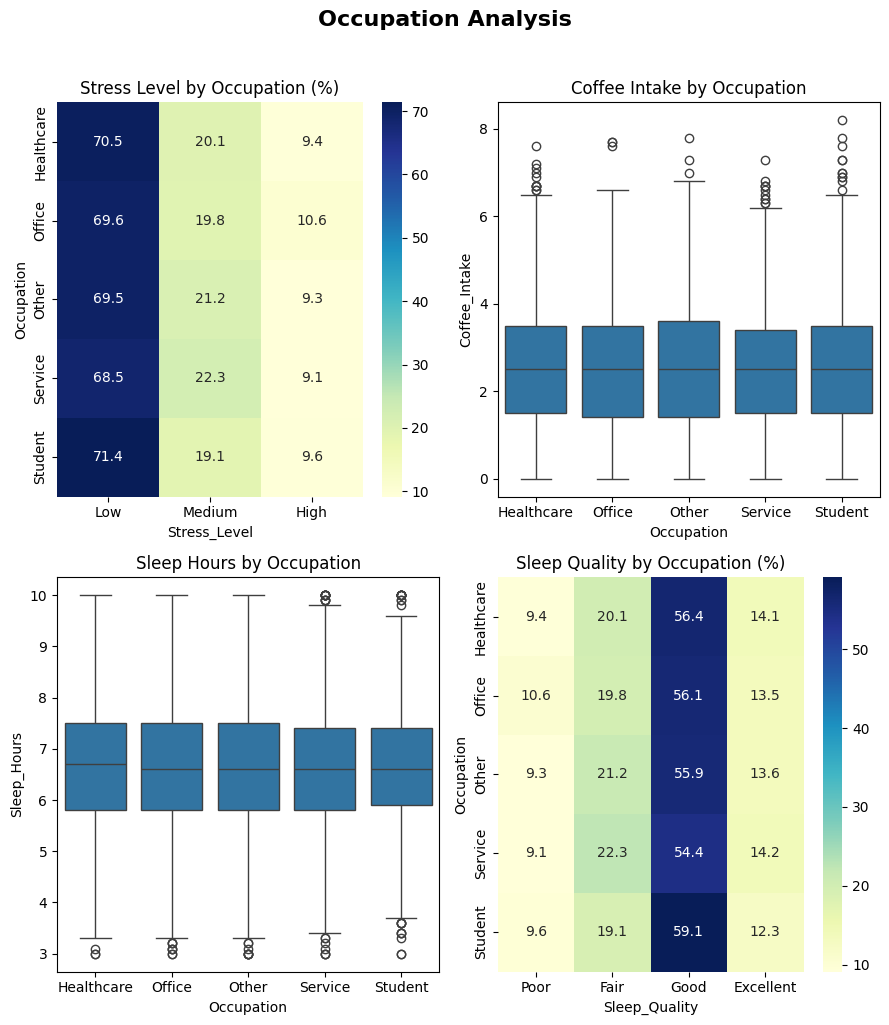

In [ ]:
fig3, axes3 = plt.subplots(nrows=2, ncols=2, figsize=(9, 10))
fig3.suptitle('Occupation Analysis', fontsize=16, fontweight='bold', y=1.02)

ordem_stress = ['Low', 'Medium', 'High']
ct = pd.crosstab(df['Occupation'], df['Stress_Level'], normalize='index')*100
ct = ct[[c for c in ordem_stress if c in ct.columns]]
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes3[0, 0])
axes3[0, 0].set_title('Stress Level by Occupation (%)')

ordem_cafe = df.groupby('Occupation')['Coffee_Intake'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Occupation', y='Coffee_Intake', order=ordem_cafe, ax=axes3[0, 1])
axes3[0, 1].set_title('Coffee Intake by Occupation')

ordem_sono = df.groupby('Occupation')['Sleep_Hours'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Occupation', y='Sleep_Hours', order=ordem_sono, ax=axes3[1, 0])
axes3[1, 0].set_title('Sleep Hours by Occupation')

ordem_quality = ['Poor', 'Fair', 'Good', 'Excellent']
ct1 = pd.crosstab(df['Occupation'], df['Sleep_Quality'], normalize='index')*100
ct1 = ct1[[c for c in ordem_quality if c in ct1.columns]]
sns.heatmap(ct1, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes3[1, 1])
axes3[1, 1].set_title('Sleep Quality by Occupation (%)')

plt.tight_layout()
plt.show()

### Country vs BMI/Stress_Level/Occupation/Health_Issues/Coffee_Intake

In [69]:
# num_vars4 = ['BMI', 'Coffee_Intake']
# cat_vars4 = ['Country', 'Stress_Level', 'Occupation', 'Health_Issues']

# fig4, axes4 = plot_grid_misto(df, num_vars4, cat_vars4, title='Mixed Grid Plot of Numeric and Categorical Variables')
# plt.show()

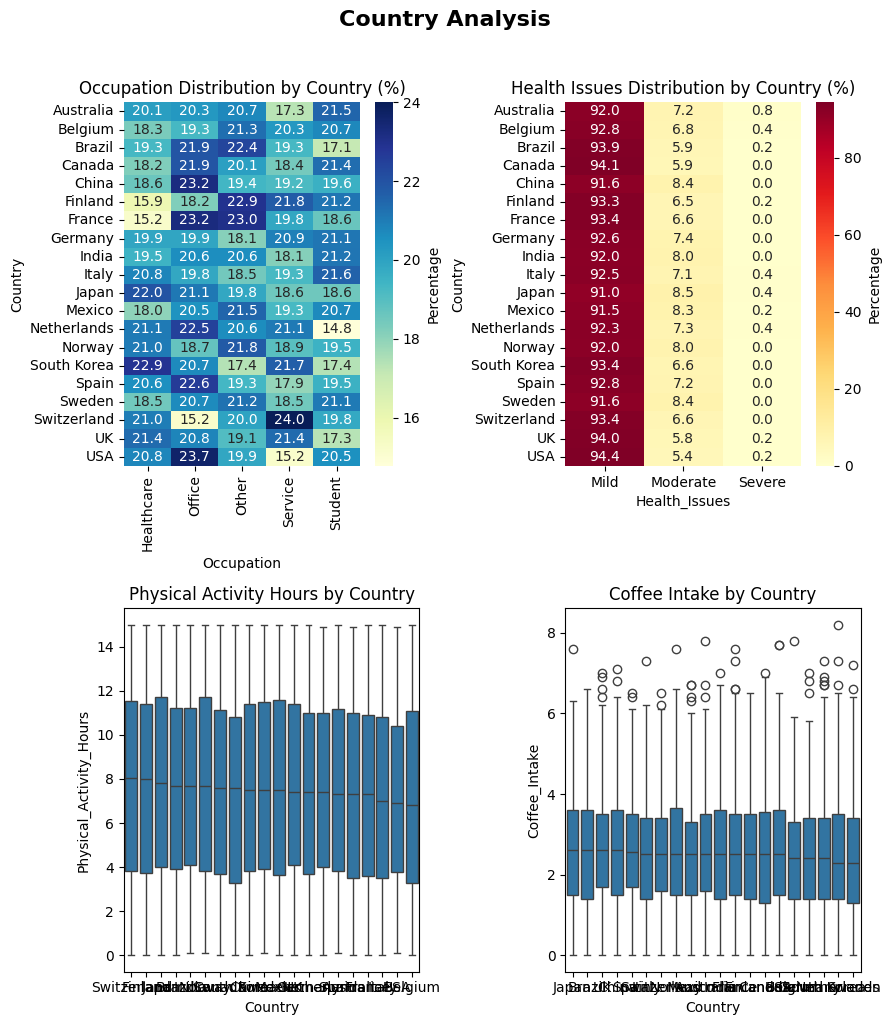

In [81]:
fig4, axes4 = plt.subplots(nrows=2, ncols=2, figsize=(9, 10))
fig4.suptitle('Country Analysis', fontsize=16, fontweight='bold', y=1.02)

ct1 = pd.crosstab(df['Country'], df['Occupation'], normalize = 'index')*100
sns.heatmap(ct1, annot=True, fmt='.1f', cmap='YlGnBu', ax=axes4[0, 0], cbar_kws={'label': 'Percentage'})
axes4[0, 0].set_title('Occupation Distribution by Country (%)')

ct2 = pd.crosstab(df['Country'], df['Health_Issues'], normalize = 'index')*100
sns.heatmap(ct2, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes4[0, 1], cbar_kws={'label': 'Percentage'})
axes4[0, 1].set_title('Health Issues Distribution by Country (%)')

ordem_ativ = df.groupby('Country')['Physical_Activity_Hours'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Country', y='Physical_Activity_Hours', order=ordem_ativ, ax=axes4[1, 0])
axes4[1, 0].set_title('Physical Activity Hours by Country')

ordem_cafe = df.groupby('Country')['Coffee_Intake'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Country', y='Coffee_Intake', order=ordem_cafe, ax=axes4[1, 1])
axes4[1, 1].set_title('Coffee Intake by Country')

plt.tight_layout()
plt.show()

### Gender vs Occupation/Health_Issues/Physical_Activity_Hours/Coffee_Intake

In [70]:
# num_vars5 = ['Physical_Activity_Hours', 'Coffee_Intake']
# cat_vars5 = ['Gender', 'Occupation', 'Health_Issues']

# fig5, axes5 = plot_grid_misto(df, num_vars5, cat_vars5, title='Mixed Grid Plot of Numeric and Categorical Variables')
# plt.show()

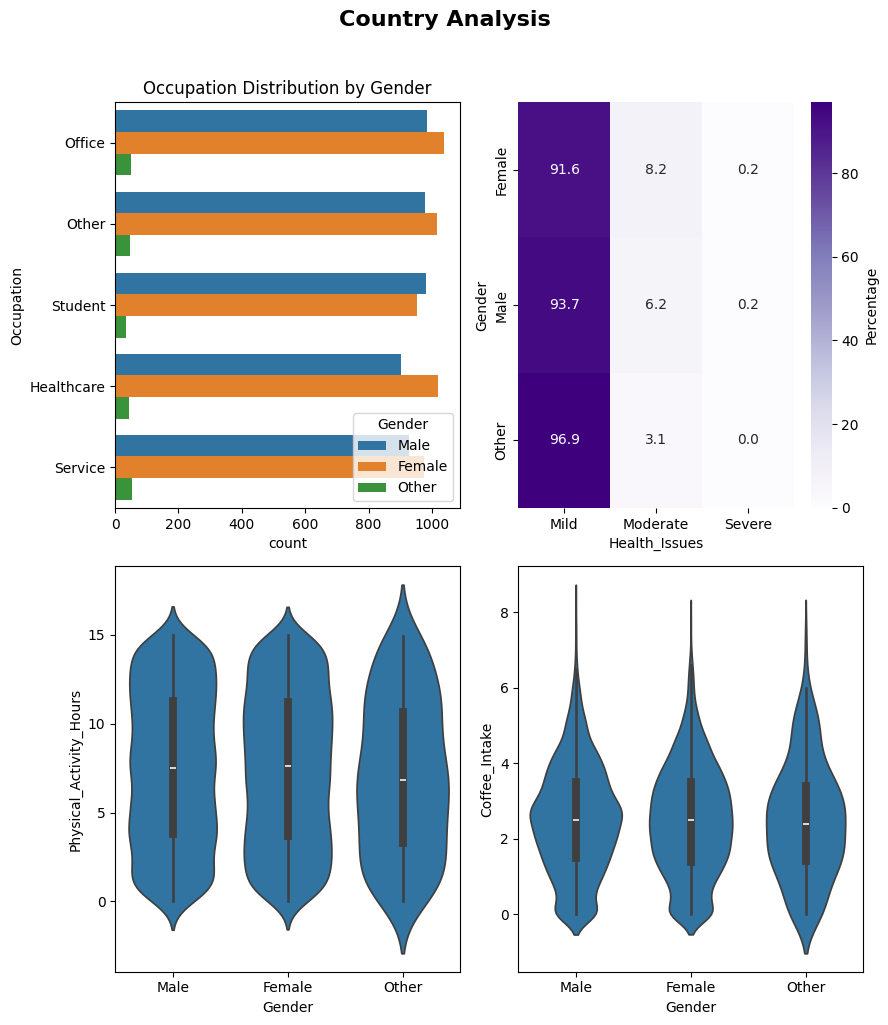

In [82]:
fig5, axes5 = plt.subplots(nrows=2, ncols=2, figsize=(9, 10))
fig5.suptitle('Country Analysis', fontsize=16, fontweight='bold', y=1.02)

ordem_occ = df['Occupation'].value_counts().index
sns.countplot(data=df, y='Occupation', hue='Gender', order=ordem_occ, ax=axes5[0, 0])
axes5[0, 0].set_title('Occupation Distribution by Gender')

ct = pd.crosstab(df['Gender'], df['Health_Issues'], normalize='index')*100
sns.heatmap(ct, annot=True, fmt = '.1f', cmap='Purples', ax=axes5[0, 1], cbar_kws={'label':'Percentage'})
axes5[0, 1].set_title('')

sns.violinplot(data=df, x='Gender', y='Physical_Activity_Hours',ax=axes5[1, 0])
axes5[1, 0].set_title('')

sns.violinplot(data=df, x='Gender', y='Coffee_Intake', ax=axes5[1, 1])
axes5[1, 1].set_title('')

plt.tight_layout()
plt.show()

Análise Exploratória de Dados (EDA)

A empresa Health&Life Analytics precisa entender melhor o perfil dos clientes e como o consumo de café se relaciona com aspectos de saúde.
Nosso primeiro passo será realizar uma análise exploratória completa, identificando padrões e potenciais problemas nos dados.
A Atividade

    Carregue o dataset em um notebook.
        Verifique dimensões, colunas, tipos de dados, nulos e duplicados.
        Gere estatísticas descritivas iniciais.

    Explore as variáveis numéricas.
        Crie histogramas, boxplots e distribuições para analisar tendências.

    Explore as variáveis categóricas.
        Crie gráficos de barras e pizzas para visualizar frequências.

    Investigue possíveis correlações.
        Exemplo: relação entre consumo de café e horas de sono, estresse e qualidade do sono.

    Documente seus achados no notebook com texto e gráficos explicativos.


Visualização e Insights

Após entender a estrutura dos dados, precisamos gerar visualizações e análises comparativas que tragam valor para o negócio.
O objetivo é comunicar de forma clara como o café, o estresse e outros fatores impactam o sono.
A Atividade

    Construa gráficos comparativos que relacionem variáveis do conjunto de dados.
        Utilize diferentes tipos de visualização (dispersão, boxplots, mapas de calor, entre outros).

    Faça análises segmentadas por grupos:
        Diferenças de sono por gênero.
        Idade e estresse em conjunto com consumo de café.

    Identifique padrões e escreva insights de negócio:
        “Clientes com alto consumo de cafeína dormem em média X horas a menos.”
        “O nível de estresse X altera [...] a qualidade do sono.”

    Prepare uma breve seção no notebook chamada Principais Descobertas, onde você lista os achados mais relevantes com gráficos.


Modelo preditivo

O time deseja prever a qualidade do sono (Sleep_Quality) com base nos hábitos e características dos clientes.
Nosso último passo será preparar os dados e implementar modelos de classificação.
A atividade

    Faça o pré-processamento dos dados:
        Remova ou trate colunas irrelevantes.
        Aplique codificação em variáveis categóricas.
        Crie pelo menos uma feature derivada.

    Divida os dados em treino e teste.

    Treine pelo menos dois modelos de classificação sendo, Sleep_Quality, a variável alvo (target).
        Compare resultados usando acurácia, matriz de confusão e/ou relatório de classificação.

    Documente a avaliação:
        Qual modelo performou melhor?
        Há overfitting ou underfitting?

    Salve o dataset final processado em CSV.

    Salve o modelo que se saiu melhor.

    Adicione uma seção Recomendações para o Negócio, explicando como os resultados podem ajudar a empresa a orientar clientes sobre hábitos de café e sono.


Durante nossa revisão, usamos como guia alguns pontos importantes que sua implementação deve seguir.

Recomendamos que você autoavalie seu projeto antes da submissão e observe se ele segue a maior parte desses pontos.
Pontos gerais

    O repositório Git submetido é acessível publicamente?
    O repositório contém um README.md explicando o objetivo do projeto, como rodar e quais bibliotecas são necessárias?
    O projeto roda corretamente em Jupyter Notebook ou Google Colab (sem erros de execução nas células)?
    O dataset está disponível ou indicado no repositório?

Entrega #1 – Análise exploratória (EDA)

    O notebook apresenta uma análise exploratória inicial?
    Foram gerados gráficos adequados para as variáveis numéricas?
    Foram gerados gráficos adequados para as variáveis categóricas?
    Há comentários claros e insights sobre os padrões encontrados?

Entrega #2 – Visualização e insights

    Foram criados gráficos comparativos relacionando consumo de café e sono?
    Houve segmentação por grupos?
    Há pelo menos uma seção de Principais Descobertas documentando os insights obtidos?
    Os gráficos estão legíveis (títulos, legendas, eixos claros)?

Entrega #3 – Modelo preditivo

    Foi feito pré-processamento dos dados (remoção de colunas irrelevantes, encoding de categóricas, criação de features)?
    Os dados foram corretamente divididos em treino e teste?
    Pelo menos dois modelos de classificação foram treinados e avaliados?
    Foram exibidas métricas de avaliação (acurácia, matriz de confusão, relatório de classificação)?
    O dataset final foi salvo em CSV?
    O modelo que teve a melhor performance foi salvo?
    Há uma seção Recomendações para o Negócio explicando como os resultados podem apoiar decisões?